# リスク分析 — ローリング指標 / 時系列 / GBM予測 / ポートフォリオ

### 構成
1. セットアップ & データ取得（過去3年弱）
2. ローリング指標ユーティリティ
3. **直近3ヶ月 × 20日ローリング**
    - ① 全30銘柄ポートフォリオ（等加重）
    - ② セクター別ポートフォリオ
    - ③ セクター内30銘柄個別
4. **2年スパン × 3ヶ月（60日）ローリング** — 過去どの時点で買っていたらどうだったか
5. **GBM予測（1銘柄、対話的）** — シグマバンド + VaR
6. **3銘柄ポートフォリオ（対話的）** — 相関ベースの分散効果 + ポートフォリオVaR
7. データ書き出し / 次の分析メモ

## 1. セットアップ & データ取得

In [6]:
import logging, warnings
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.stats import norm
import ipywidgets as widgets
from IPython.display import display

# Mac で確実に出る日本語フォントのみ指定 → 警告なし
plt.rcParams['font.family'] = 'Hiragino Sans'
plt.rcParams['axes.unicode_minus'] = False

# Seaborn でリッチなテーマ
sns.set_theme(style='whitegrid', context='notebook', font='Hiragino Sans', rc={'axes.unicode_minus': False})

ROOT = Path.cwd().parent if Path.cwd().name == 'analysis' else Path.cwd()

# パラメータ
WINDOW = 20            # 短期ローリング（≒1ヶ月）
WINDOW_3M = 60         # 3ヶ月ローリング
DISPLAY_MONTHS = 3     # セクション3 の表示期間
DISPLAY_YEARS_LONG = 2 # セクション4 の表示期間
TRADING_DAYS = 252
RF = 0.0

to_date = datetime.today()
from_date = to_date - timedelta(days=365 * (DISPLAY_YEARS_LONG + 1))  # 余裕を持って3年取る
print(f'取得期間: {from_date.date()} 〜 {to_date.date()}')

取得期間: 2023-05-20 〜 2026-05-19


In [7]:
stocks = pd.read_csv(ROOT / 'data' / 'stocks.csv')
stocks['ticker'] = stocks['code'].astype(str).str.zfill(4) + '.T'
name_to_sector = dict(zip(stocks['name'], stocks['sector']))
ticker_to_name = dict(zip(stocks['ticker'], stocks['name']))
SECTORS = ['エンタメ', '運輸', '小売']
SECTOR_COLORS = {'エンタメ': '#ef4444', '運輸': '#3b82f6', '小売': '#10b981'}

raw = yf.download(
    stocks['ticker'].tolist(),
    start=from_date.strftime('%Y-%m-%d'),
    end=to_date.strftime('%Y-%m-%d'),
    auto_adjust=True,
    progress=False,
    group_by='ticker',
)
close = pd.concat(
    {ticker_to_name[t]: raw[t]['Close'] for t in stocks['ticker'] if t in raw.columns.get_level_values(0)},
    axis=1,
).dropna(how='all').sort_index()
returns = close.pct_change().dropna(how='all')
ALL_STOCKS = list(returns.columns)
print(f'価格 shape={close.shape}, リターン shape={returns.shape}')

価格 shape=(730, 30), リターン shape=(729, 30)


## 2. ローリング指標ユーティリティ

- 年率リターン: $\mu = \bar{r} \times 252$
- 年率ボラ: $\sigma = \text{std}(r) \times \sqrt{252}$
- シャープ: $(\mu - r_f)/\sigma$

In [8]:
def rolling_metrics(series_or_df, window):
    vol = series_or_df.rolling(window).std() * np.sqrt(TRADING_DAYS)
    mu = series_or_df.rolling(window).mean() * TRADING_DAYS
    sharpe = (mu - RF) / vol
    return mu, vol, sharpe

def trim_by_days(df, days):
    cutoff = pd.Timestamp(to_date) - pd.Timedelta(days=days)
    return df[df.index >= cutoff]

## 3. 直近3ヶ月 × 20日ローリング

### ① 全30銘柄ポートフォリオ（等加重）

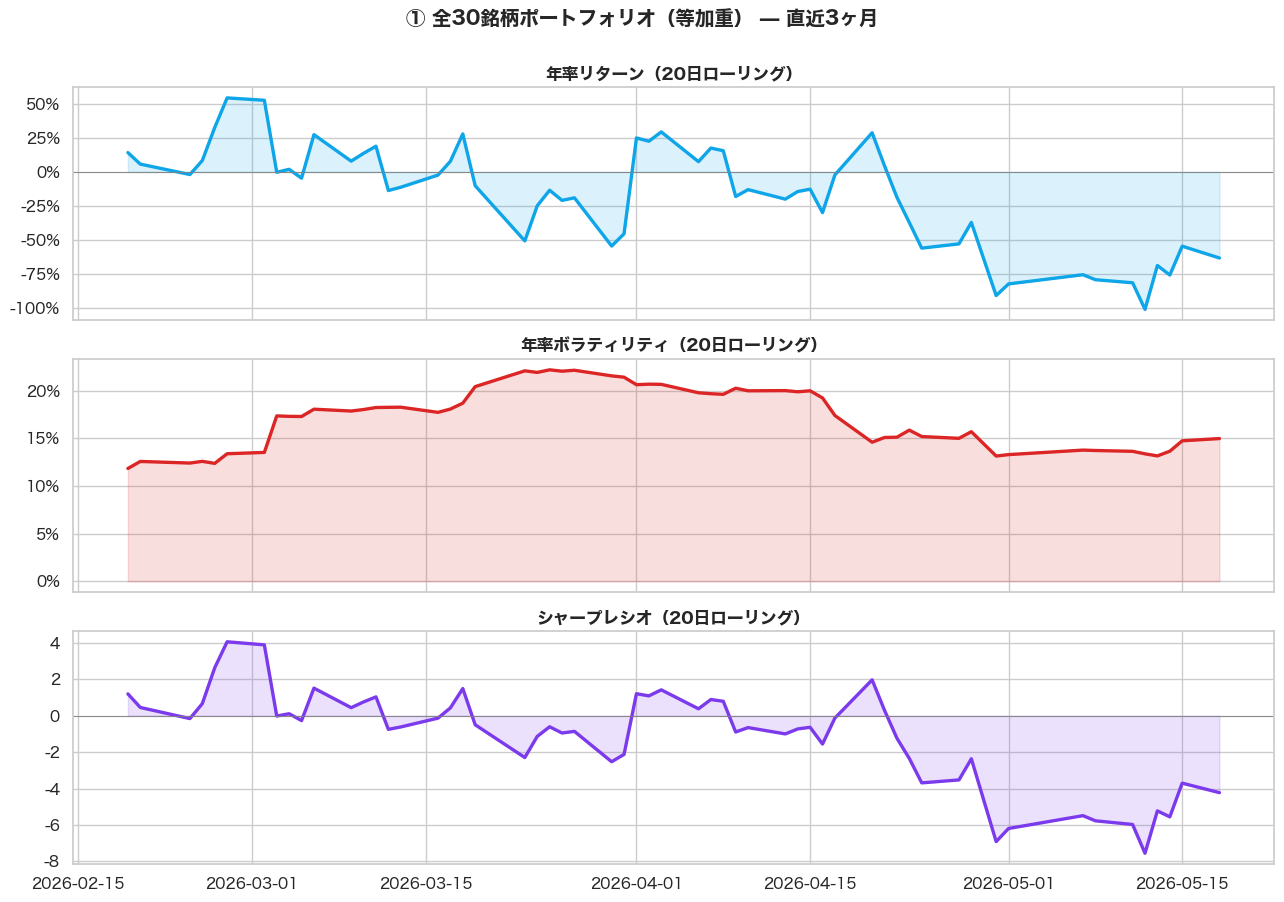

In [4]:
port_all = returns.mean(axis=1)
mu_all, vol_all, sharpe_all = (trim_by_days(x, 30 * DISPLAY_MONTHS) for x in rolling_metrics(port_all, WINDOW))

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
axes[0].plot(mu_all.index, mu_all.values, color='#0ea5e9', linewidth=2.4)
axes[0].fill_between(mu_all.index, mu_all.values, 0, color='#0ea5e9', alpha=0.15)
axes[0].axhline(0, color='gray', linewidth=0.6)
axes[0].set_title(f'年率リターン（{WINDOW}日ローリング）', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

axes[1].plot(vol_all.index, vol_all.values, color='#dc2626', linewidth=2.4)
axes[1].fill_between(vol_all.index, vol_all.values, 0, color='#dc2626', alpha=0.15)
axes[1].set_title(f'年率ボラティリティ（{WINDOW}日ローリング）', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

axes[2].plot(sharpe_all.index, sharpe_all.values, color='#7c3aed', linewidth=2.4)
axes[2].fill_between(sharpe_all.index, sharpe_all.values, 0, color='#7c3aed', alpha=0.15)
axes[2].axhline(0, color='gray', linewidth=0.6)
axes[2].set_title(f'シャープレシオ（{WINDOW}日ローリング）', fontsize=12, fontweight='bold')

fig.suptitle('① 全30銘柄ポートフォリオ（等加重） — 直近3ヶ月', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout(); plt.show()

### ② セクター別ポートフォリオ

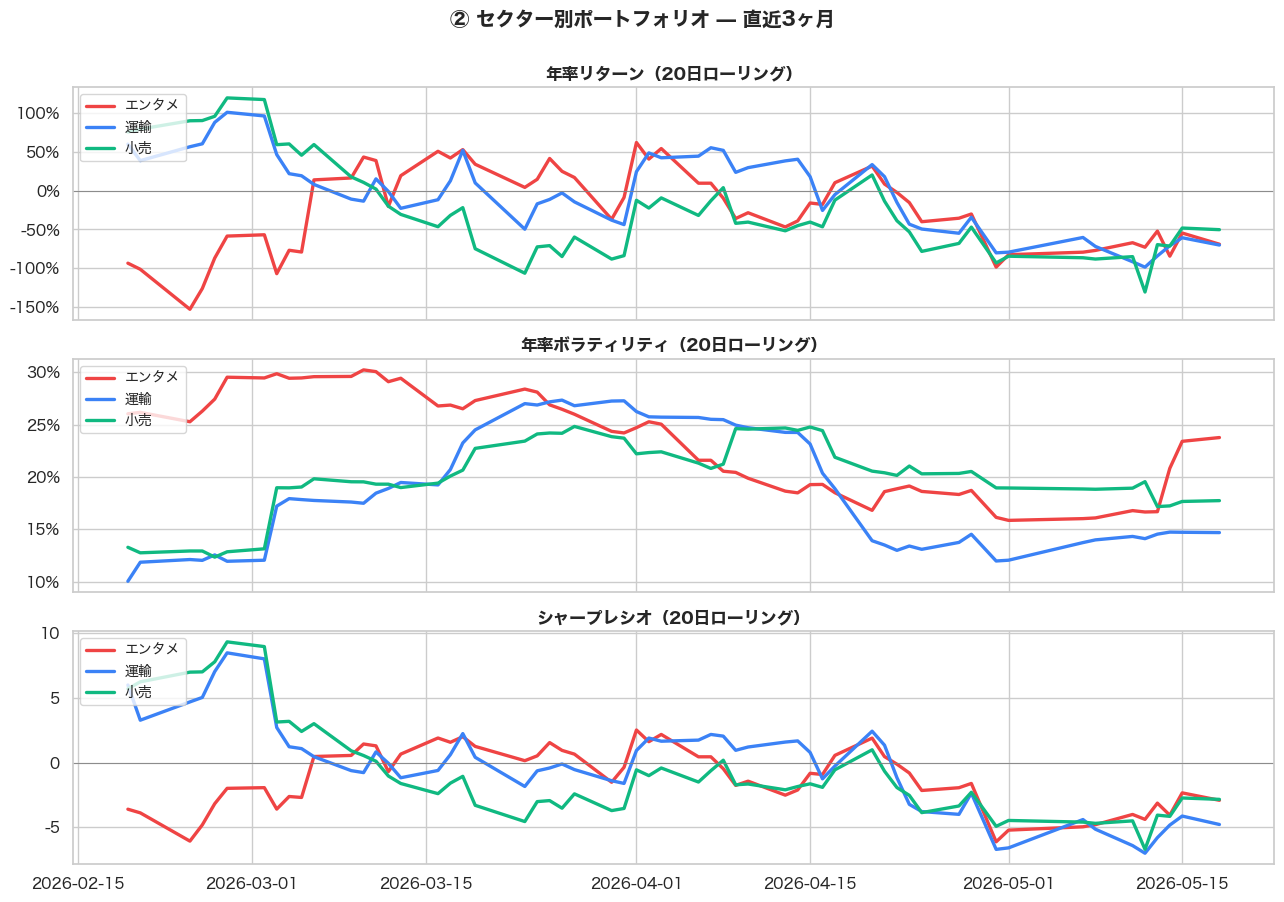

In [5]:
sector_port = pd.DataFrame({
    s: returns[[n for n in returns.columns if name_to_sector.get(n) == s]].mean(axis=1)
    for s in SECTORS
})
mu_sec, vol_sec, sharpe_sec = (trim_by_days(x, 30 * DISPLAY_MONTHS) for x in rolling_metrics(sector_port, WINDOW))

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for s in SECTORS:
    axes[0].plot(mu_sec.index, mu_sec[s], label=s, color=SECTOR_COLORS[s], linewidth=2.4)
    axes[1].plot(vol_sec.index, vol_sec[s], label=s, color=SECTOR_COLORS[s], linewidth=2.4)
    axes[2].plot(sharpe_sec.index, sharpe_sec[s], label=s, color=SECTOR_COLORS[s], linewidth=2.4)
axes[0].axhline(0, color='gray', linewidth=0.6); axes[2].axhline(0, color='gray', linewidth=0.6)
axes[0].set_title(f'年率リターン（{WINDOW}日ローリング）', fontsize=12, fontweight='bold')
axes[1].set_title(f'年率ボラティリティ（{WINDOW}日ローリング）', fontsize=12, fontweight='bold')
axes[2].set_title(f'シャープレシオ（{WINDOW}日ローリング）', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
for ax in axes:
    ax.legend(loc='upper left', fontsize=10, frameon=True)
fig.suptitle('② セクター別ポートフォリオ — 直近3ヶ月', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout(); plt.show()

### ③ セクター内30銘柄個別

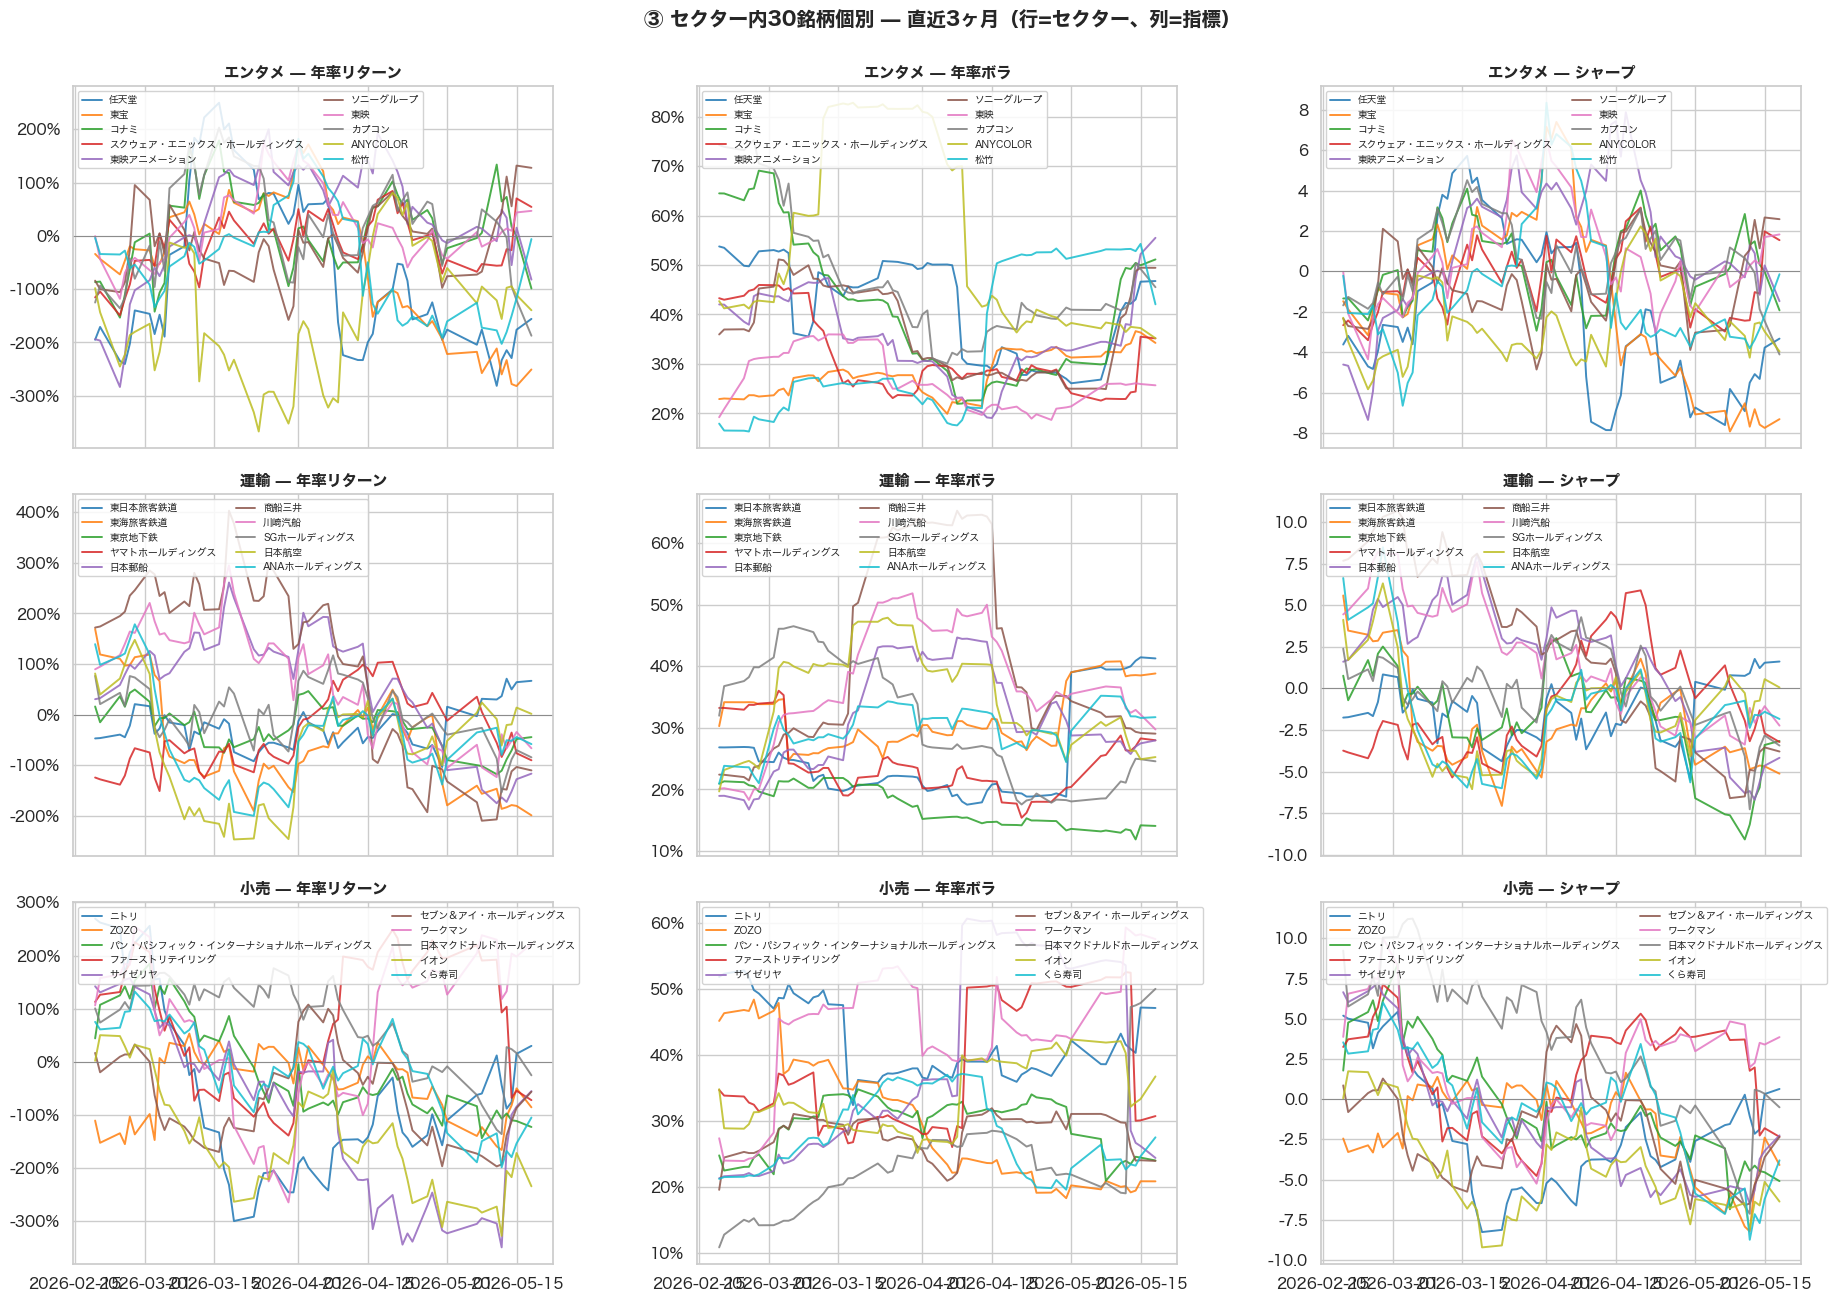

In [6]:
mu_ind_3m, vol_ind_3m, sharpe_ind_3m = (
    trim_by_days(x, 30 * DISPLAY_MONTHS) for x in rolling_metrics(returns, WINDOW)
)

fig, axes = plt.subplots(3, 3, figsize=(19, 13), sharex=True)
metric_labels = ['年率リターン', '年率ボラ', 'シャープ']
metric_dfs = [mu_ind_3m, vol_ind_3m, sharpe_ind_3m]

for row, sector in enumerate(SECTORS):
    cols = [n for n in returns.columns if name_to_sector.get(n) == sector]
    palette = sns.color_palette('tab10', n_colors=len(cols))
    for col, (label, df) in enumerate(zip(metric_labels, metric_dfs)):
        ax = axes[row, col]
        for c, color in zip(cols, palette):
            ax.plot(df.index, df[c], label=c, color=color, alpha=0.85, linewidth=1.4)
        ax.set_title(f'{sector} — {label}', fontsize=11, fontweight='bold')
        if label != 'シャープ':
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
        if label != '年率ボラ':
            ax.axhline(0, color='gray', linewidth=0.6)
        ax.legend(fontsize=7, ncol=2, loc='upper left', framealpha=0.85)

fig.suptitle('③ セクター内30銘柄個別 — 直近3ヶ月（行=セクター、列=指標）', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout(); plt.show()

---

## 4. 2年スパン × 3ヶ月（60日）ローリング

「もし**過去のあの時点で買っていたら**、直前の3ヶ月リスク・リターンはどう見えていたか」を時系列で見る。
x軸=過去2年、各点=その点までの **60営業日（≒3ヶ月）** のリスク・リターン。

In [7]:
DAYS_2Y = 365 * DISPLAY_YEARS_LONG

# 全銘柄等加重
port_all_3m_mu, port_all_3m_vol, port_all_3m_sh = rolling_metrics(port_all, WINDOW_3M)
# セクター
mu_sec_3m, vol_sec_3m, sh_sec_3m = rolling_metrics(sector_port, WINDOW_3M)
# 個別
mu_ind_long, vol_ind_long, sh_ind_long = rolling_metrics(returns, WINDOW_3M)

# 表示期間でトリム
port_all_3m_mu = trim_by_days(port_all_3m_mu, DAYS_2Y)
port_all_3m_vol = trim_by_days(port_all_3m_vol, DAYS_2Y)
port_all_3m_sh = trim_by_days(port_all_3m_sh, DAYS_2Y)
mu_sec_3m = trim_by_days(mu_sec_3m, DAYS_2Y)
vol_sec_3m = trim_by_days(vol_sec_3m, DAYS_2Y)
sh_sec_3m = trim_by_days(sh_sec_3m, DAYS_2Y)
mu_ind_long = trim_by_days(mu_ind_long, DAYS_2Y)
vol_ind_long = trim_by_days(vol_ind_long, DAYS_2Y)
sh_ind_long = trim_by_days(sh_ind_long, DAYS_2Y)

### ④-1. 全30銘柄ポートフォリオ（等加重） — 2年 × 3ヶ月ローリング

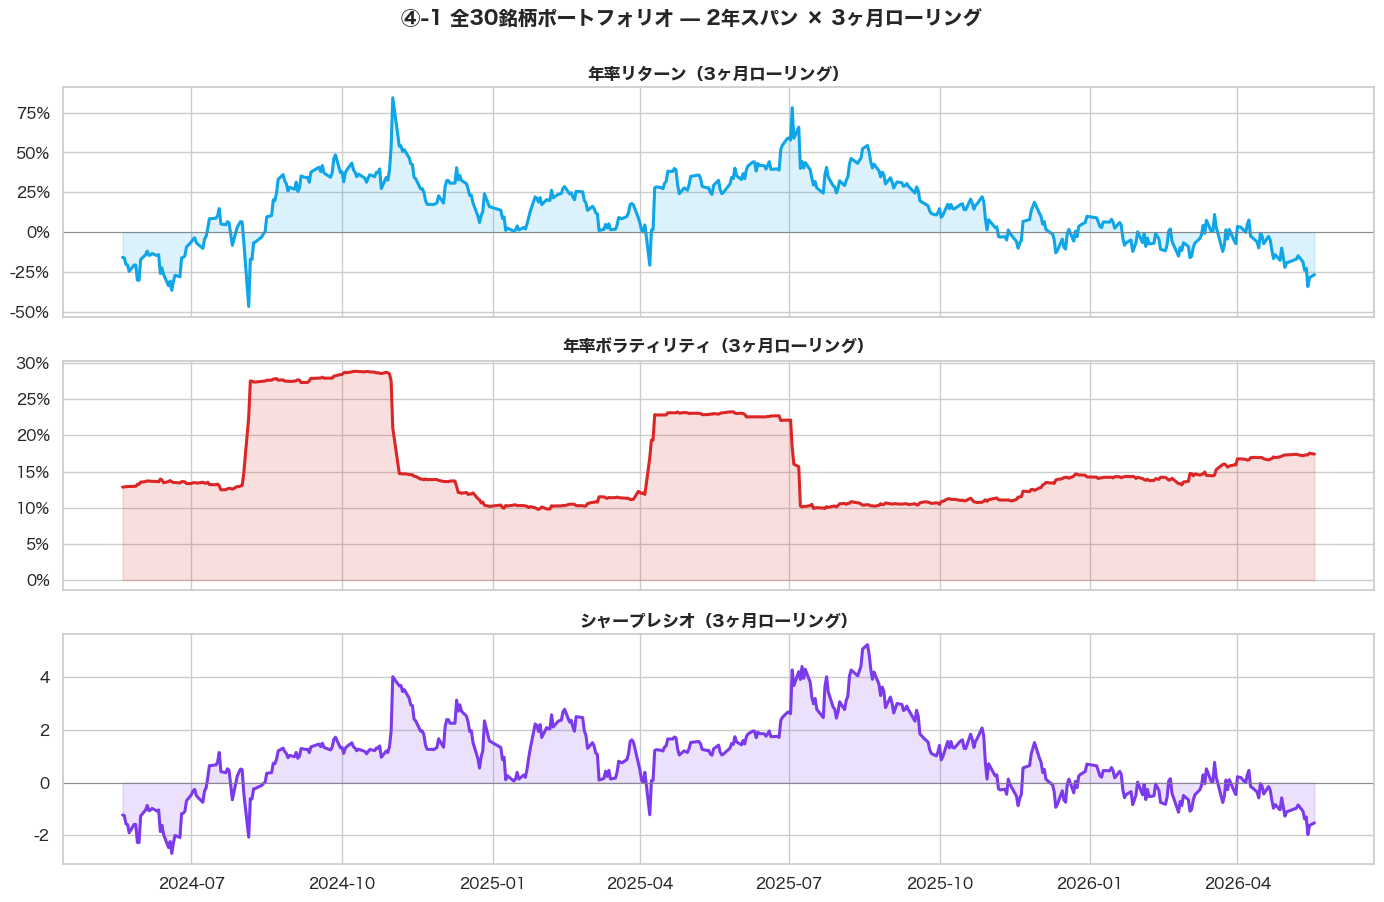

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(port_all_3m_mu.index, port_all_3m_mu, color='#0ea5e9', linewidth=2.2)
axes[0].fill_between(port_all_3m_mu.index, port_all_3m_mu, 0, color='#0ea5e9', alpha=0.15)
axes[0].axhline(0, color='gray', linewidth=0.6)
axes[0].set_title('年率リターン（3ヶ月ローリング）', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

axes[1].plot(port_all_3m_vol.index, port_all_3m_vol, color='#dc2626', linewidth=2.2)
axes[1].fill_between(port_all_3m_vol.index, port_all_3m_vol, 0, color='#dc2626', alpha=0.15)
axes[1].set_title('年率ボラティリティ（3ヶ月ローリング）', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

axes[2].plot(port_all_3m_sh.index, port_all_3m_sh, color='#7c3aed', linewidth=2.2)
axes[2].fill_between(port_all_3m_sh.index, port_all_3m_sh, 0, color='#7c3aed', alpha=0.15)
axes[2].axhline(0, color='gray', linewidth=0.6)
axes[2].set_title('シャープレシオ（3ヶ月ローリング）', fontsize=12, fontweight='bold')

fig.suptitle('④-1 全30銘柄ポートフォリオ — 2年スパン × 3ヶ月ローリング', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout(); plt.show()

### ④-2. セクター別ポートフォリオ — 2年 × 3ヶ月ローリング

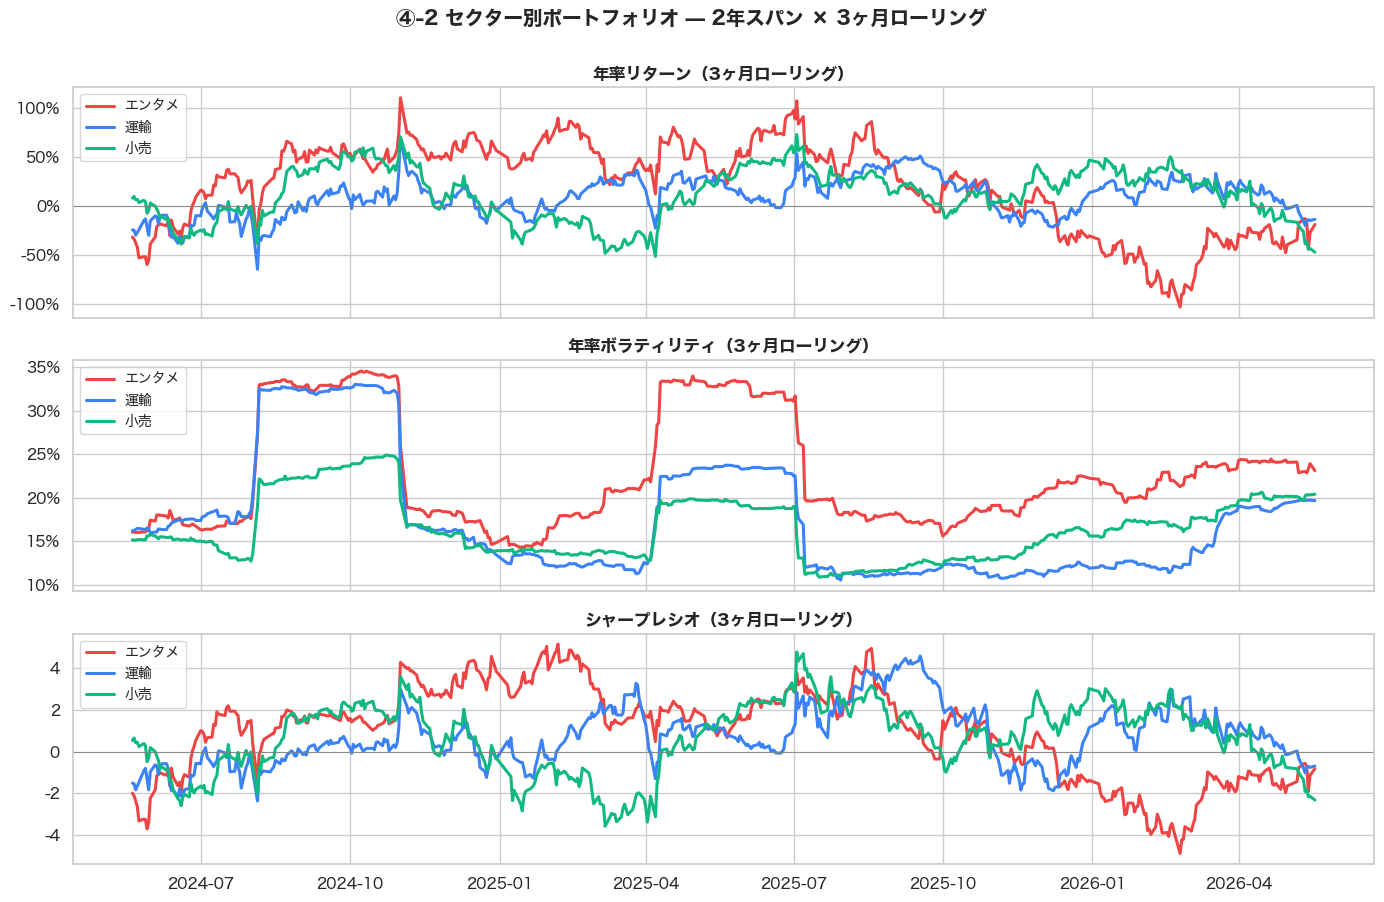

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for s in SECTORS:
    axes[0].plot(mu_sec_3m.index, mu_sec_3m[s], label=s, color=SECTOR_COLORS[s], linewidth=2.2)
    axes[1].plot(vol_sec_3m.index, vol_sec_3m[s], label=s, color=SECTOR_COLORS[s], linewidth=2.2)
    axes[2].plot(sh_sec_3m.index, sh_sec_3m[s], label=s, color=SECTOR_COLORS[s], linewidth=2.2)
axes[0].axhline(0, color='gray', linewidth=0.6); axes[2].axhline(0, color='gray', linewidth=0.6)
axes[0].set_title('年率リターン（3ヶ月ローリング）', fontsize=12, fontweight='bold')
axes[1].set_title('年率ボラティリティ（3ヶ月ローリング）', fontsize=12, fontweight='bold')
axes[2].set_title('シャープレシオ（3ヶ月ローリング）', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
for ax in axes:
    ax.legend(loc='upper left', fontsize=10, frameon=True)
fig.suptitle('④-2 セクター別ポートフォリオ — 2年スパン × 3ヶ月ローリング', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout(); plt.show()

### ④-3. セクター内30銘柄個別 — 2年 × 3ヶ月ローリング

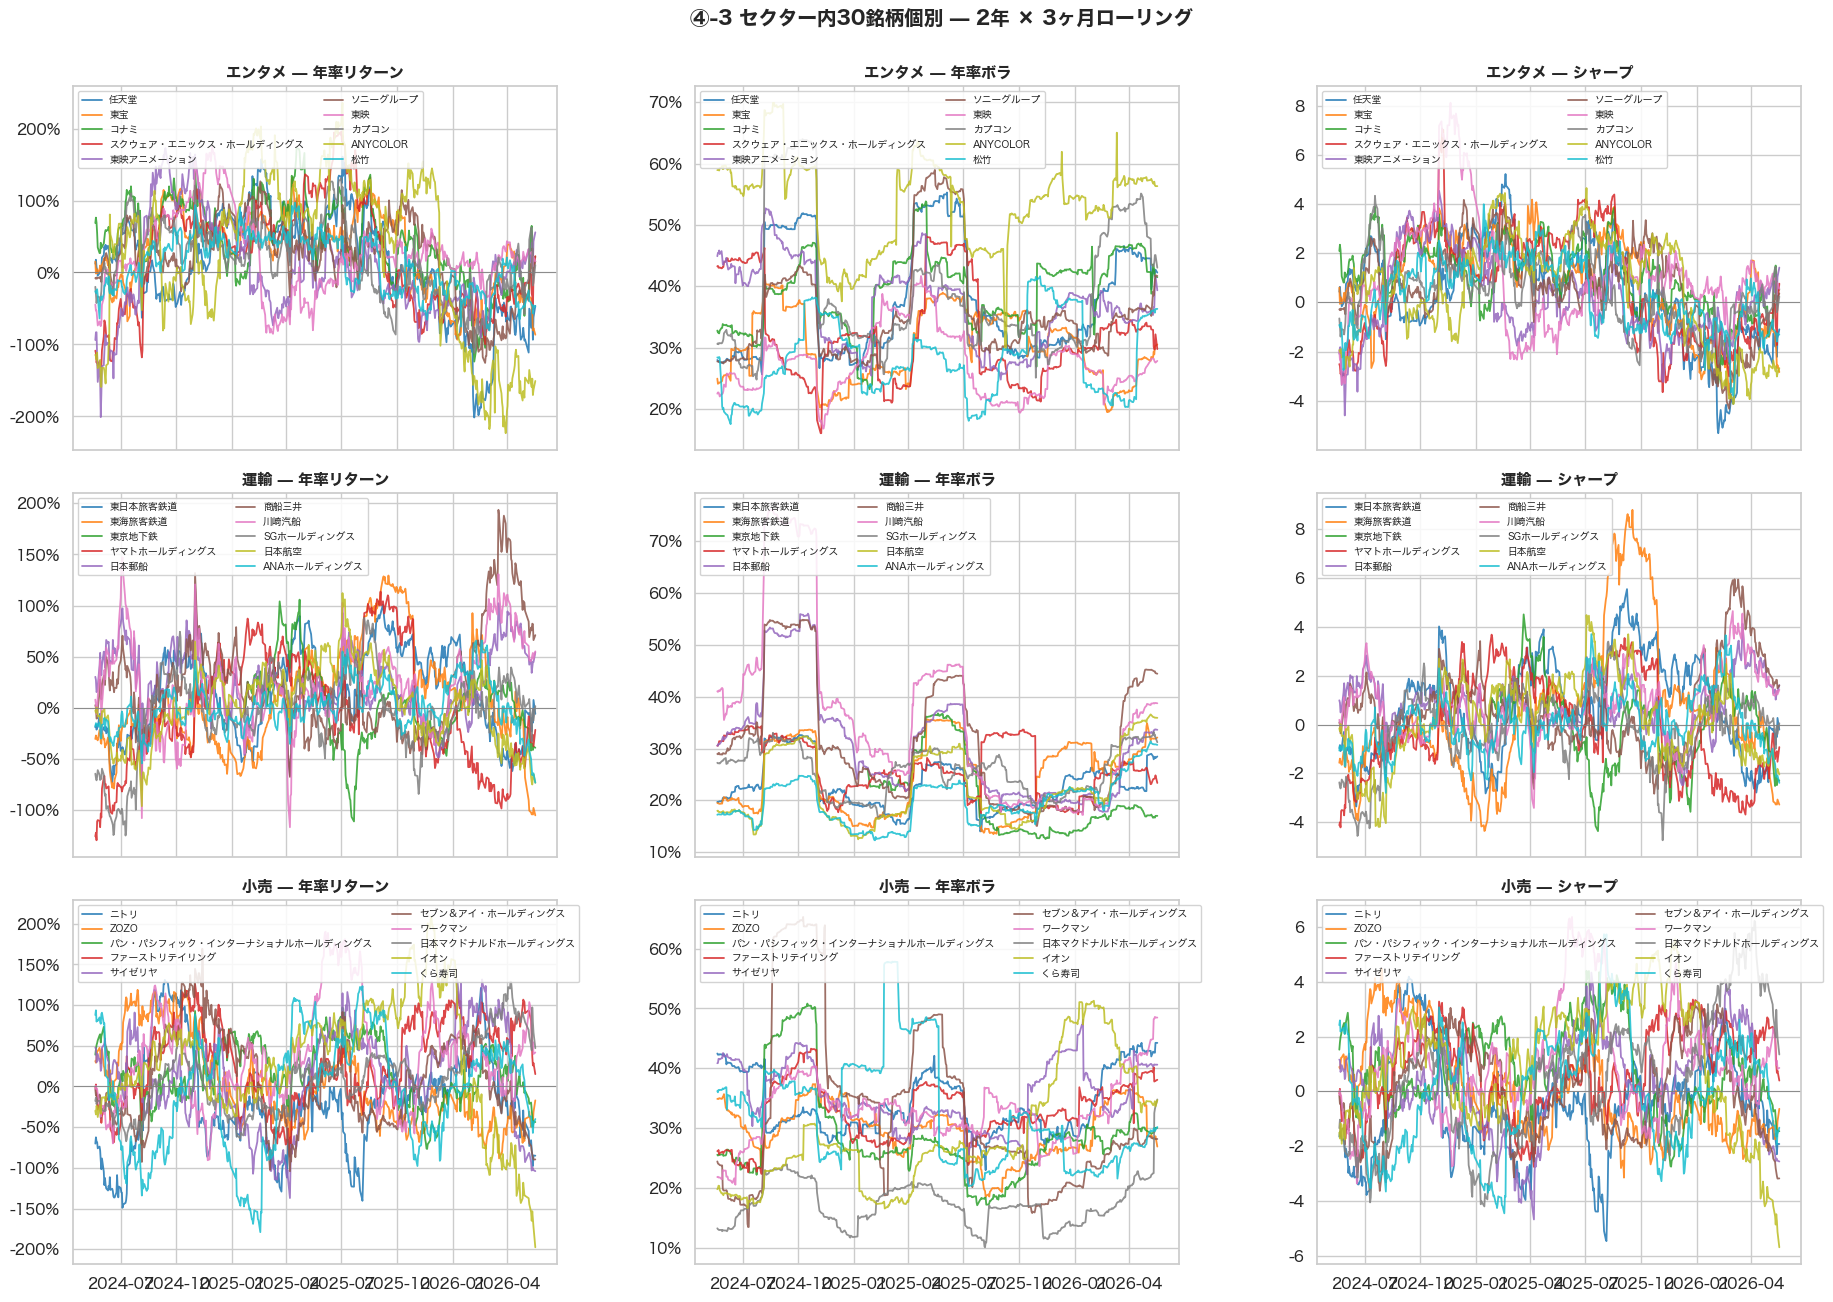

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(19, 13), sharex=True)
metric_labels = ['年率リターン', '年率ボラ', 'シャープ']
metric_dfs = [mu_ind_long, vol_ind_long, sh_ind_long]

for row, sector in enumerate(SECTORS):
    cols = [n for n in returns.columns if name_to_sector.get(n) == sector]
    palette = sns.color_palette('tab10', n_colors=len(cols))
    for col, (label, df) in enumerate(zip(metric_labels, metric_dfs)):
        ax = axes[row, col]
        for c, color in zip(cols, palette):
            ax.plot(df.index, df[c], label=c, color=color, alpha=0.85, linewidth=1.3)
        ax.set_title(f'{sector} — {label}', fontsize=11, fontweight='bold')
        if label != 'シャープ':
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
        if label != '年率ボラ':
            ax.axhline(0, color='gray', linewidth=0.6)
        ax.legend(fontsize=7, ncol=2, loc='upper left', framealpha=0.85)

fig.suptitle('④-3 セクター内30銘柄個別 — 2年 × 3ヶ月ローリング', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout(); plt.show()

### 直近値スナップショット

In [11]:
snapshot = pd.DataFrame({
    'sector': mu_ind_long.columns.map(name_to_sector),
    'mu_3m': mu_ind_long.iloc[-1],
    'vol_3m': vol_ind_long.iloc[-1],
    'sharpe_3m': sh_ind_long.iloc[-1],
}).sort_values(['sector', 'sharpe_3m'], ascending=[True, False])
snapshot.style.format({'mu_3m': '{:.2%}', 'vol_3m': '{:.2%}', 'sharpe_3m': '{:.2f}'}).background_gradient(
    subset=['sharpe_3m'], cmap='RdYlGn'
).background_gradient(subset=['vol_3m'], cmap='Reds')

,sector,mu_3m,vol_3m,sharpe_3m
東映アニメーション,エンタメ,55.80%,39.34%,1.42
スクウェア・エニックス・ホールディングス,エンタメ,22.75%,29.76%,0.76
東映,エンタメ,15.36%,27.83%,0.55
コナミ,エンタメ,21.61%,41.48%,0.52
ソニーグループ,エンタメ,15.27%,41.69%,0.37
カプコン,エンタメ,10.21%,43.03%,0.24
任天堂,エンタメ,-46.34%,42.23%,-1.10
松竹,エンタメ,-47.66%,36.31%,-1.31
ANYCOLOR,エンタメ,-150.78%,56.32%,-2.68
東宝,エンタメ,-86.50%,30.50%,-2.84


---

## 5. GBM予測（1銘柄）— シグマバンド + VaR

幾何ブラウン運動 $dS_t = \mu S_t dt + \sigma S_t dW_t$ を仮定。

$\ln(S_t / S_0) \sim \mathcal{N}\big((\mu - \sigma^2/2)t,\ \sigma^2 t\big)$

中央値の周囲に ±1σ, ±2σ, ±3σ の帯を色分け。VaR は信頼水準別の最悪損失水準。

**操作**: 銘柄選択 / 推定窓 / 予測日数を切替えると即時再描画。`μ手動上書き` ON で μ・σ をスライダーで指定可能。

In [12]:
def gbm_bands(S0, mu, sigma, horizon_days):
    dt = 1 / TRADING_DAYS
    t = np.arange(horizon_days + 1) * dt
    log_mean = (mu - sigma**2 / 2) * t
    log_std = sigma * np.sqrt(t)
    median = S0 * np.exp(log_mean)
    expected = S0 * np.exp(mu * t)
    bands = {k: (S0 * np.exp(log_mean - k * log_std), S0 * np.exp(log_mean + k * log_std)) for k in [1, 2, 3]}
    return t, median, expected, bands

def var_levels(S0, mu, sigma, horizon_days, confidences=(0.95, 0.99)):
    T = horizon_days / TRADING_DAYS
    out = {}
    log_mean_T = (mu - sigma**2 / 2) * T
    log_std_T = sigma * np.sqrt(T)
    for c in confidences:
        price_at_var = S0 * np.exp(log_mean_T + log_std_T * norm.ppf(1 - c))
        out[c] = {'price': price_at_var, 'loss_pct': 1 - price_at_var / S0, 'loss_jpy': S0 - price_at_var}
    return out

def estimate_mu_sigma(name, window):
    r = returns[name].dropna().iloc[-window:]
    return r.mean() * TRADING_DAYS, r.std() * np.sqrt(TRADING_DAYS)

In [13]:
BAND_PALETTE = ['#fde68a', '#fdba74', '#fca5a5']  # ±1σ → ±3σ

def plot_single_forecast(stock, window, horizon_days, mu_override, sigma_override, use_override):
    series = close[stock].dropna()
    S0 = series.iloc[-1]
    last_date = series.index[-1]
    mu_est, sigma_est = estimate_mu_sigma(stock, window)
    mu = mu_override if use_override else mu_est
    sigma = sigma_override if use_override else sigma_est

    t, median, expected, bands = gbm_bands(S0, mu, sigma, horizon_days)
    var = var_levels(S0, mu, sigma, horizon_days)
    forecast_dates = pd.bdate_range(last_date, periods=horizon_days + 1)

    hist = series.iloc[-90:]

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(hist.index, hist.values, color='#0f172a', linewidth=1.8, label='実績')
    for (k, (lo, hi)), c in zip(bands.items(), BAND_PALETTE):
        ax.fill_between(forecast_dates, lo, hi, color=c, alpha=0.6, label=f'±{k}σ')
    ax.plot(forecast_dates, median, color='#1e293b', linestyle='--', linewidth=1.6, label='中央値')
    ax.plot(forecast_dates, expected, color='#2563eb', linestyle=':', linewidth=1.4, label='期待値')

    ax.axhline(var[0.95]['price'], color='#dc2626', linewidth=1.3, linestyle='-.', alpha=0.85)
    ax.axhline(var[0.99]['price'], color='#7f1d1d', linewidth=1.3, linestyle='-.', alpha=0.85)
    ax.annotate(f"VaR 95% : ¥{var[0.95]['price']:,.0f} ({var[0.95]['loss_pct']:.1%})",
                xy=(forecast_dates[-1], var[0.95]['price']), xytext=(8, 0), textcoords='offset points',
                color='#dc2626', va='center', fontsize=9, fontweight='bold')
    ax.annotate(f"VaR 99% : ¥{var[0.99]['price']:,.0f} ({var[0.99]['loss_pct']:.1%})",
                xy=(forecast_dates[-1], var[0.99]['price']), xytext=(8, 0), textcoords='offset points',
                color='#7f1d1d', va='center', fontsize=9, fontweight='bold')
    ax.axvline(last_date, color='gray', linewidth=0.6)

    used = '手動' if use_override else f'{window}日推定'
    ax.set_title(
        f'{stock} — GBM予測（{horizon_days}営業日 ≒ {horizon_days/21:.1f}ヶ月）\n'
        f'現在値 ¥{S0:,.0f} / μ={mu:.1%} / σ={sigma:.1%} ({used})',
        fontsize=12, fontweight='bold'
    )
    ax.set_ylabel('株価 (円)')
    ax.legend(loc='upper left', fontsize=9, frameon=True)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'¥{x:,.0f}'))
    plt.tight_layout(); plt.show()

stock_dd = widgets.Dropdown(options=ALL_STOCKS, value='任天堂', description='銘柄')
window_dd = widgets.Dropdown(options=[10, 20, 60, 120], value=60, description='推定窓')
horizon_sl = widgets.IntSlider(value=63, min=21, max=126, step=7, description='予測日数', continuous_update=False)
use_override_cb = widgets.Checkbox(value=False, description='μ/σ手動上書き')
mu_sl = widgets.FloatSlider(value=0.10, min=-1.0, max=1.5, step=0.05, description='μ(年率)', readout_format='.0%', continuous_update=False)
sigma_sl = widgets.FloatSlider(value=0.30, min=0.05, max=1.5, step=0.05, description='σ(年率)', readout_format='.0%', continuous_update=False)

ui = widgets.VBox([
    widgets.HBox([stock_dd, window_dd, horizon_sl]),
    widgets.HBox([use_override_cb, mu_sl, sigma_sl]),
])
out = widgets.interactive_output(plot_single_forecast, {
    'stock': stock_dd, 'window': window_dd, 'horizon_days': horizon_sl,
    'mu_override': mu_sl, 'sigma_override': sigma_sl, 'use_override': use_override_cb,
})
display(ui, out)

Output()

---

## 6. 3銘柄ポートフォリオ — 相関ベースのリスク

$\mu_p = \mathbf{w}^\top \boldsymbol{\mu}, \quad \sigma_p = \sqrt{\mathbf{w}^\top \Sigma \mathbf{w}}$

- $\Sigma$ は3銘柄の共分散行列（年率化）
- 相関を無視した加重平均ボラ $\sigma_{naive} = \mathbf{w}^\top \boldsymbol{\sigma}$ と比較して **分散効果**
- 同じGBM枠組みでポートフォリオ価値（初期100）の3ヶ月先分布とVaR

In [14]:
def estimate_cov(names, window):
    r = returns[list(names)].dropna().iloc[-window:]
    mu = r.mean().values * TRADING_DAYS
    cov = r.cov().values * TRADING_DAYS
    corr = r.corr().values
    sigma = np.sqrt(np.diag(cov))
    return mu, sigma, cov, corr

def plot_portfolio(s1, s2, s3, w1, w2, w3, window, horizon_days):
    names = [s1, s2, s3]
    raw_w = np.array([w1, w2, w3], dtype=float)
    if raw_w.sum() == 0:
        raw_w = np.ones(3)
    w = raw_w / raw_w.sum()

    mu_i, sigma_i, cov, corr = estimate_cov(names, window)
    mu_p = float(w @ mu_i)
    sigma_p = float(np.sqrt(w @ cov @ w))
    sigma_naive = float(w @ sigma_i)
    diversification = 1 - sigma_p / sigma_naive if sigma_naive > 0 else 0
    sharpe_p = (mu_p - RF) / sigma_p if sigma_p > 0 else np.nan

    S0 = 100.0
    t, median, expected, bands = gbm_bands(S0, mu_p, sigma_p, horizon_days)
    var = var_levels(S0, mu_p, sigma_p, horizon_days)

    last_date = returns.index[-1]
    forecast_dates = pd.bdate_range(last_date, periods=horizon_days + 1)

    hist_window = 90
    port_ret = (returns[names].iloc[-hist_window:] * w).sum(axis=1)
    hist_value = (1 + port_ret).cumprod()
    hist_value = hist_value / hist_value.iloc[-1] * S0

    fig = plt.figure(figsize=(16, 9))
    gs = fig.add_gridspec(2, 3, width_ratios=[2.4, 1, 1], height_ratios=[1, 1])

    ax_main = fig.add_subplot(gs[:, 0])
    ax_main.plot(hist_value.index, hist_value.values, color='#0f172a', linewidth=1.8, label='実績(正規化)')
    for (k, (lo, hi)), c in zip(bands.items(), BAND_PALETTE):
        ax_main.fill_between(forecast_dates, lo, hi, color=c, alpha=0.6, label=f'±{k}σ')
    ax_main.plot(forecast_dates, median, color='#1e293b', linestyle='--', linewidth=1.6, label='中央値')
    ax_main.plot(forecast_dates, expected, color='#2563eb', linestyle=':', linewidth=1.4, label='期待値')
    ax_main.axhline(var[0.95]['price'], color='#dc2626', linewidth=1.3, linestyle='-.', alpha=0.85)
    ax_main.axhline(var[0.99]['price'], color='#7f1d1d', linewidth=1.3, linestyle='-.', alpha=0.85)
    ax_main.annotate(f"VaR 95% : {var[0.95]['price']:.1f} ({var[0.95]['loss_pct']:.1%})",
                     xy=(forecast_dates[-1], var[0.95]['price']), xytext=(8, 0), textcoords='offset points',
                     color='#dc2626', va='center', fontsize=9, fontweight='bold')
    ax_main.annotate(f"VaR 99% : {var[0.99]['price']:.1f} ({var[0.99]['loss_pct']:.1%})",
                     xy=(forecast_dates[-1], var[0.99]['price']), xytext=(8, 0), textcoords='offset points',
                     color='#7f1d1d', va='center', fontsize=9, fontweight='bold')
    ax_main.axvline(last_date, color='gray', linewidth=0.6)
    ax_main.set_title(
        f'ポートフォリオ予測 — {horizon_days}営業日（≒{horizon_days/21:.1f}ヶ月）\n'
        f'μ_p={mu_p:.1%}  σ_p={sigma_p:.1%}  Sharpe={sharpe_p:.2f}  分散効果={diversification:.1%}',
        fontsize=12, fontweight='bold'
    )
    ax_main.legend(loc='upper left', fontsize=9, frameon=True)
    ax_main.set_ylabel('ポートフォリオ価値（初期=100）')

    # ウェイト
    ax_w = fig.add_subplot(gs[0, 1])
    palette3 = ['#ef4444', '#3b82f6', '#10b981']
    bars = ax_w.barh(names, w * 100, color=palette3)
    for bar, val in zip(bars, w * 100):
        ax_w.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=9)
    ax_w.set_xlim(0, max(w * 100) * 1.3 + 5)
    ax_w.set_title('ウェイト', fontweight='bold')
    ax_w.invert_yaxis()

    # 個別 μ/σ
    ax_metrics = fig.add_subplot(gs[0, 2])
    x = np.arange(3)
    ax_metrics.bar(x - 0.2, mu_i * 100, width=0.4, color='#0ea5e9', label='μ(年率)')
    ax_metrics.bar(x + 0.2, sigma_i * 100, width=0.4, color='#dc2626', label='σ(年率)')
    ax_metrics.set_xticks(x)
    ax_metrics.set_xticklabels([n[:5] for n in names], fontsize=8)
    ax_metrics.set_ylabel('%')
    ax_metrics.legend(fontsize=8)
    ax_metrics.set_title('個別 μ / σ', fontweight='bold')
    ax_metrics.axhline(0, color='gray', linewidth=0.5)

    # 相関ヒートマップ
    ax_corr = fig.add_subplot(gs[1, 1:])
    sns.heatmap(
        pd.DataFrame(corr, index=[n[:6] for n in names], columns=[n[:6] for n in names]),
        annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, center=0,
        ax=ax_corr, cbar_kws={'shrink': 0.7}, square=False, annot_kws={'fontsize': 10}
    )
    ax_corr.set_title('相関行列', fontweight='bold')

    plt.tight_layout(); plt.show()

ps1 = widgets.Dropdown(options=ALL_STOCKS, value='任天堂', description='銘柄1')
ps2 = widgets.Dropdown(options=ALL_STOCKS, value='ソニーグループ', description='銘柄2')
ps3 = widgets.Dropdown(options=ALL_STOCKS, value='東日本旅客鉄道', description='銘柄3')
pw1 = widgets.FloatSlider(value=1.0, min=0.0, max=1.0, step=0.05, description='w1', readout_format='.2f', continuous_update=False)
pw2 = widgets.FloatSlider(value=1.0, min=0.0, max=1.0, step=0.05, description='w2', readout_format='.2f', continuous_update=False)
pw3 = widgets.FloatSlider(value=1.0, min=0.0, max=1.0, step=0.05, description='w3', readout_format='.2f', continuous_update=False)
pwindow = widgets.Dropdown(options=[20, 60, 120, 252], value=60, description='推定窓')
phorizon = widgets.IntSlider(value=63, min=21, max=126, step=7, description='予測日数', continuous_update=False)

ui_p = widgets.VBox([
    widgets.HBox([ps1, pw1]),
    widgets.HBox([ps2, pw2]),
    widgets.HBox([ps3, pw3]),
    widgets.HBox([pwindow, phorizon]),
])
out_p = widgets.interactive_output(plot_portfolio, {
    's1': ps1, 's2': ps2, 's3': ps3, 'w1': pw1, 'w2': pw2, 'w3': pw3,
    'window': pwindow, 'horizon_days': phorizon,
})
display(ui_p, out_p)

Output()

### 読み方

- **μ_p**: ポートフォリオ年率期待リターン（個別μの加重和）
- **σ_p**: 共分散行列ベースのポートフォリオ年率ボラ（**相関を考慮した本当のリスク**）
- **分散効果**: $1 - \sigma_p / \sigma_{naive}$。値が大きいほど相関の低い銘柄を組合せている
- **VaR 95% / 99%**: 3ヶ月後の最悪損失水準（信頼水準別）
- **相関行列**: 0.5以上は同方向の動き → 分散効果が薄い。負相関はヘッジ効果

ゲームの150万円制約に置き換えるなら、`VaR 95% の損失%` × 1.5M円 が「3ヶ月で覚悟する金額」。

---

## 7. データ書き出し / 次の分析メモ

In [15]:
OUT = ROOT / 'analysis' / 'output'
OUT.mkdir(exist_ok=True)
snapshot.to_csv(OUT / 'risk_snapshot.csv')
mu_ind_long.to_csv(OUT / 'rolling_return_3m.csv')
vol_ind_long.to_csv(OUT / 'rolling_vol_3m.csv')
sh_ind_long.to_csv(OUT / 'rolling_sharpe_3m.csv')
print('saved to', OUT)

saved to /Users/yoshikinakanishi/Documents/IA/portfolio-game/analysis/output


### 次にやると効きそうな分析

**A. ゲームルール直結**
- 150万円制約下の単元株シミュレータ（`現在値 × 単元数 × 数量` で買える組合せ一覧）
- 2日ロック対応の期待損益（反対売買禁止期間を加味）
- 任意銘柄スクリーニング（時価総額≥100億・上場≥1年）

**B. 仮説立案**
- 最大ドローダウン (MDD)、モメンタム、出来高サージ

**C. リスク高度化**
- モンテカルロ・シミュレーション → 経験的VaR / 期待ショートフォール (ES)
- TOPIX (1306.T) との β、階層クラスタリング、効率的フロンティア（3銘柄の最適ウェイト）

**D. イベント・ファンダ**
- 決算日カレンダー、アナリストコンセンサス、PER/PBR/配当利回り